# AraDQ — disease-symptom quantification of flood-inoculated *Arabidopsis* seedlings

**Paper:** Jae Hoon Lee, Unseok Lee, Ji Hye Yoo, Taek Sung Lee, Je Hyeong Jung, Hyoung Seok Kim.
*AraDQ: an automated digital phenotyping software for quantifying disease symptoms of flood-inoculated Arabidopsis seedlings.*
Plant Methods **20**:44 (2024). DOI [10.1186/s13007-024-01171-w](https://doi.org/10.1186/s13007-024-01171-w) · PMCID [PMC10943777](https://pmc.ncbi.nlm.nih.gov/articles/PMC10943777/)

**Author release:** `kist-smartfarm/AraDQ` (commit `1ebfe20875b51f429e5deeed7db468e9847f954b`, README-only) and the AraDQ v0.1.3 package + Case Study 1/2 datasets linked from its README (Google Drive).

## What this notebook does (exact scope)

Runs the **released AraDQ analysis pipeline** — the authors' own trained YOLOv4 palette
detector and U-net segmentation model — on **two paired Case Study 1 plate photographs**
(Col-0 / WT *Pst* DC3000 at OD 0.005, replicate 1, before inoculation `0d` and 3 days
post-inoculation `3d`), and reproduces the full 15-column per-seedling trait CSV
(GCC, ExGI, GRVI, five HSV hue-class areas, perimeter, projected leaf area, convex-hull
perimeter/area, compactness, stockiness) plus the paper's 0d-to-3d fold-change view.

**Status: executed demonstration on a minimal example.** This is *not* a reproduction of
the paper's dataset-level statistics (those average 6 seedlings x 6 replicates per condition).

## Provenance & transparency statement (important)

**AI-assisted reimplementation.** The authors released a Windows PyInstaller application
rather than runnable Python source. The pipeline logic (homography targets in cm, CameraTrax
reference RGB table, modified-gamma color-correction model, corner-ordering heuristic, trait
formulas) was recovered from the released application's own bundled Python modules
(`main.py`, `utils.py`, `colorbalance.py`, `segmentation/predict.py`) by bytecode
decompilation **inside this notebook's runtime**, and is re-implemented here against the
paper's Methods section. The trained models (YOLOv4 `colorcard_last.weights` + `colorcard.cfg`,
U-net `ara_segmentation_model.h5`) are the authors' original files, used unmodified and
downloaded directly from their release inside this notebook. **The authors did not endorse
this Colab implementation; untested behaviour is not guaranteed.**

Known deviations (documented in the corresponding cells):
- The app's default detector is a keras-retinanet model that cannot load in modern TensorFlow; we use the app's own alternative `colorcard2` path (the released Darknet YOLOv4 via OpenCV DNN).
- The app's dense-CRF mask refinement (`pydensecrf`) is omitted (no compatible wheel for current Python); the raw sigmoid > 0.5 mask is used.
- The app pads its segmentation input to a square; we follow the recovered logic.

**日本語:** 本ノートブックは AraDQ (Plant Methods 2024) の公開解析パイプラインを、著者公開の
学習済みモデル (YOLOv4 + U-net) とアプリ内蔵ロジックから復元した定数で最小例 (Case Study 1 の
0d/3d 対画像 1 対) 上で実行します。AI による再実装であり著者の承認を得たものではありません。

## Runtime

**CPU runtime is sufficient** (Runtime -> Change runtime type -> CPU). No GPU is required:
per image the detector runs one 480x480 YOLOv4 inference and the U-net one 1024x1024
inference. Observed end-to-end time on a fresh Colab CPU VM: a few minutes, dominated by
the ~950 MB downloads (AraDQ package 772 MB + Case Study 1 data 173 MB). All dataset,
weight and program bytes stay on the Colab VM (`/content`).


## 1. Environment: pin OpenCV 4.x (before any cv2 import)

Colab's preinstalled OpenCV 5.x removed the Darknet importer (`cv2.dnn.readNetFromDarknet`)
that the authors' `colorcard2` mode relies on. We replace it with `opencv-python-headless 4.11.0.86`
**before** importing cv2, then record the actual runtime environment. Expected result: cv2 4.11.x
with the Darknet reader available.

**日本語:** 著者の colorcard2 モードが必要とする Darknet 読み込みのため、OpenCV を 4.11 に固定します。

In [ ]:
%pip uninstall -y -q opencv-python opencv-contrib-python opencv-python-headless
%pip install -q "opencv-python-headless==4.11.0.86"
import sys, subprocess, textwrap
r = subprocess.run([sys.executable, '-c', 'import cv2; print(cv2.__version__); print("darknet:", hasattr(cv2.dnn, "readNetFromDarknet"))'], capture_output=True, text=True)
print(r.stdout.strip())
import tensorflow as tf, numpy as np, scipy, skimage
print('tensorflow', tf.__version__, '| numpy', np.__version__, '| scipy', scipy.__version__, '| skimage', skimage.__version__)
assert r.returncode == 0 and '4.11' in r.stdout and 'darknet: True' in r.stdout

   ━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/50.0 MB 188.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.0/50.0 MB 142.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.0/50.0 MB 142.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.0/50.0 MB 142.8 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 17.4 MB/s eta 0:00:00


4.11.0
darknet: True


tensorflow 2.21.0 | numpy 2.1.3 | scipy 1.16.3 | skimage 0.25.2


## 2. Download the author release archives (provenance)

The two archives are downloaded from the Google Drive IDs published verbatim in the README of
`kist-smartfarm/AraDQ` at pinned commit `1ebfe20875b51f429e5deeed7db468e9847f954b`:
the **AraDQ v0.1.3 program package** (772 MB: the two trained models + the Windows app) and
**AraDQ Case Study 1 data** (173 MB, 78 plate photographs). Sizes are recorded below as a
byte-identity check against the values observed at authoring time (772,441,083 and
173,044,311 bytes).

**日本語:** 著者README記載の Google Drive からプログラムパッケージと Case Study 1 データを取得します。

In [ ]:
import gdown, os
os.makedirs('/content/aradq', exist_ok=True)
FILES = {
    'AraDQ_v0.1.3_package.zip': '1XkqQfinxOfak0U0sKG3d3Sf268zxGYkO',
    'AraDQ_casestudy1_data.zip': '1bRKd_kx48HROVTm5VRwm7cWjTJT8KYJ4',
}
for name, fid in FILES.items():
    out = f'/content/aradq/{name}'
    if not os.path.exists(out):
        gdown.download(id=fid, output=out, quiet=False)
    print(name, f'{os.path.getsize(out):,} bytes')

Downloading...
From (original): https://drive.google.com/uc?id=1XkqQfinxOfak0U0sKG3d3Sf268zxGYkO
From (redirected): https://drive.google.com/uc?id=1XkqQfinxOfak0U0sKG3d3Sf268zxGYkO&confirm=t&uuid=96481bea-4f1f-44ed-a03d-8597b87dc9e6
To: /content/aradq/AraDQ_v0.1.3_package.zip


  0%|          | 0.00/772M [00:00<?, ?B/s]

  1%|          | 5.24M/772M [00:00<00:15, 51.0MB/s]

  1%|▏         | 10.5M/772M [00:00<00:23, 32.8MB/s]

  2%|▏         | 17.3M/772M [00:00<00:19, 38.8MB/s]

...

 85%|████████▌ | 147M/173M [00:03<00:00, 47.0MB/s]

 88%|████████▊ | 153M/173M [00:03<00:00, 45.3MB/s]

 98%|█████████▊| 170M/173M [00:03<00:00, 62.5MB/s]

100%|██████████| 173M/173M [00:03<00:00, 43.5MB/s]

AraDQ_casestudy1_data.zip 173,044,311 bytes


## 3. Extract models, configs and the two paired sample images

We extract only what the minimal demonstration needs: the U-net (`ara_segmentation_model.h5`
+ its `model.json`), the YOLOv4 detector (`colorcard_last.weights`, `colorcard.cfg`,
`colorcard.names`) and the deterministic sample pair `0d_Col0_WT_0.005-1.jpg` /
`3d_Col0_WT_0.005-1.jpg` (Col-0, WT *Pst* DC3000, OD 0.005, replicate 1 — a fixed identifier,
not a hand-picked result). Expected result: all files present with non-zero sizes.

**日本語:** 最小構成に必要なモデル・設定・ペア画像 (0d/3d) のみを展開します。

In [ ]:
import zipfile, os
MEMBERS = ['weights/ara_segmetnation/ara_segmentation_model.h5', 'weights/ara_segmetnation/model.json',
           'weights/colorcard2/colorcard_last.weights', 'weights/colorcard2/colorcard.cfg', 'weights/colorcard2/colorcard.names']
SAMPLES = ['0d_Col0_WT_0.005-1.jpg', '3d_Col0_WT_0.005-1.jpg']
with zipfile.ZipFile('/content/aradq/AraDQ_v0.1.3_package.zip') as z:
    for m in MEMBERS:
        z.extract(m, '/content/aradq/program')
    print('program entries:', len(z.namelist()))
with zipfile.ZipFile('/content/aradq/AraDQ_casestudy1_data.zip') as z:
    names = z.namelist()
    print('case study images:', len(names))
    for s in SAMPLES:
        assert s in names, s
        z.extract(s, '/content/aradq/case1')
for p in MEMBERS + [f'/content/aradq/case1/{s}' for s in SAMPLES]:
    p = p if p.startswith('/content') else f'/content/aradq/program/{p}'
    print(f'{p}: {os.path.getsize(p):,} bytes')

program entries: 12
case study images: 80
/content/aradq/program/weights/ara_segmetnation/ara_segmentation_model.h5: 93,518,304 bytes
/content/aradq/program/weights/ara_segmetnation/model.json: 32,198 bytes
/content/aradq/program/weights/colorcard2/colorcard_last.weights: 256,080,600 bytes
/content/aradq/program/weights/colorcard2/colorcard.cfg: 12,253 bytes
/content/aradq/program/weights/colorcard2/colorcard.names: 22 bytes
/content/aradq/case1/0d_Col0_WT_0.005-1.jpg: 2,268,927 bytes
/content/aradq/case1/3d_Col0_WT_0.005-1.jpg: 2,179,987 bytes


## 4. Input preview — the paired plate photographs

Each photograph shows one Petri plate with up to four *Arabidopsis* seedlings on a white
background and the 2x3 inch CameraTrax 24-patch color card required by AraDQ for distortion
and color correction (paper: *Image data acquisition*). The `0d` image is the pre-inoculation
state of the same plate whose `3d` image is the disease-symptom readout. Expected result:
two RGB views, with dimensions printed from the actual files.

**日本語:** カラーカード付きのプレート写真ペア (接種前 0d / 3日後 3d) を表示します。

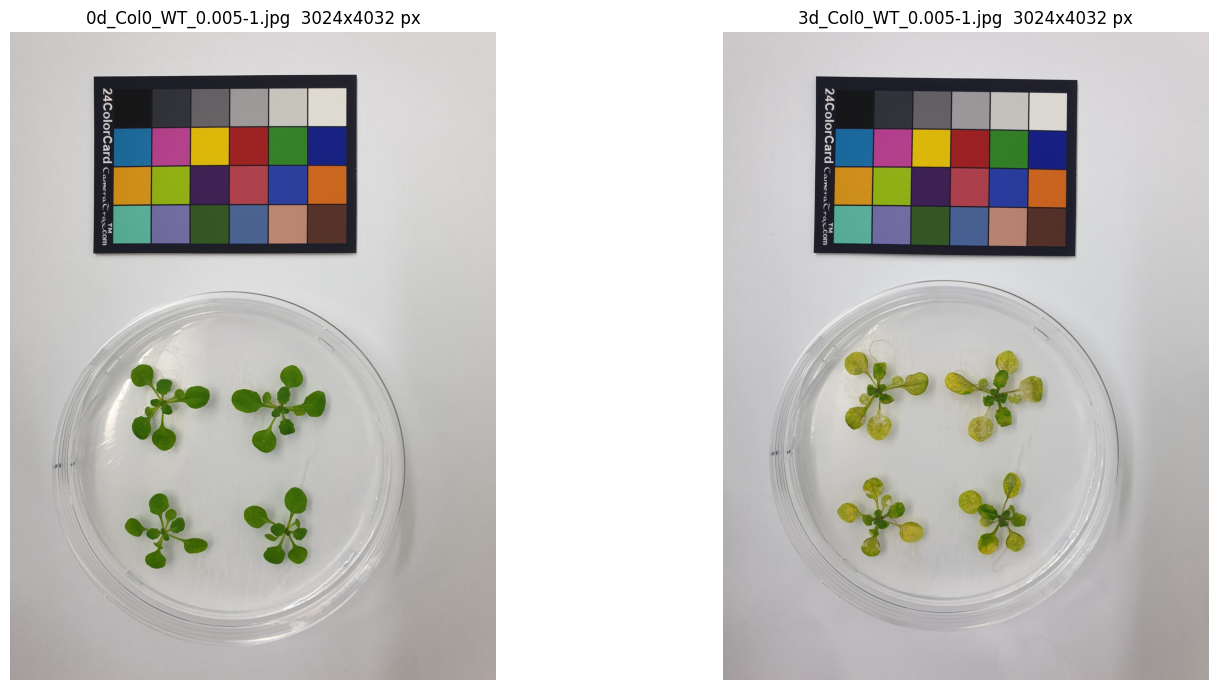

0d_Col0_WT_0.005-1.jpg (4032, 3024, 3)
3d_Col0_WT_0.005-1.jpg (4032, 3024, 3)


In [ ]:
import cv2, matplotlib.pyplot as plt
imgs = {s: cv2.imread(f'/content/aradq/case1/{s}') for s in SAMPLES}
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (s, im) in zip(axes, imgs.items()):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{s}  {im.shape[1]}x{im.shape[0]} px')
    ax.axis('off')
plt.tight_layout(); plt.show()
for s, im in imgs.items():
    print(s, im.shape)

## 5. Load the authors' U-net segmentation model

The released `ara_segmentation_model.h5` (input 1024x1024x3, output 1024x1024x1 sigmoid,
keras 2.2.4 architecture in `model.json`) loads unmodified in TensorFlow 2.x. Expected
result: model IO shapes printed; the mask is verified visually in cell 10.

**日本語:** 著者の U-net (.h5) をそのまま読み込みます (入出力形状を確認)。

In [ ]:
import tensorflow as tf
seg = tf.keras.models.load_model('/content/aradq/program/weights/ara_segmetnation/ara_segmentation_model.h5', compile=False)
print('input:', seg.inputs[0].shape, '-> output:', seg.outputs[0].shape)
print('layers:', len(seg.layers), '| final activation:', seg.layers[-1].get_config().get('activation'))

input: (None, 1024, 1024, 3) -> output: (None, 1024, 1024, 1)
layers: 68 | final activation: sigmoid


## 6. Load the authors' YOLOv4 palette detector (colorcard2 mode)

The released Darknet weights `colorcard_last.weights` + `colorcard.cfg` (480x480 input,
4 classes = brown/white/cyan/black patch edges) are loaded through OpenCV's DNN API with
the exact parameters used by the app (`scale=1/255, size=(480,480), swapRB=True`).
Expected result: class list printed; inference is exercised in the pipeline cells.

**日本語:** 著者の YOLOv4 (colorcard2 モード) を OpenCV DNN で読み込みます。

In [ ]:
import cv2
net = cv2.dnn.readNetFromDarknet('/content/aradq/program/weights/colorcard2/colorcard.cfg',
                                 '/content/aradq/program/weights/colorcard2/colorcard_last.weights')
CLASSES = open('/content/aradq/program/weights/colorcard2/colorcard.names').read().split()
detector = cv2.dnn_DetectionModel(net)
detector.setInputParams(scale=1/255.0, size=(480, 480), swapRB=True)
print('classes:', CLASSES)

classes: ['brown', 'white', 'cyan', 'black']


## 7. The AraDQ pipeline as one function (faithful port)

This cell re-implements the recovered app logic (see the transparency statement) as
`analyze_plate(path)` returning the 15-column trait table plus visualization artifacts:

1. **Segmentation first** (app order): the plate is fit into 1024x1024 with aspect
   preservation + zero padding, the U-net produces a sigmoid mask, thresholded at 0.5,
   and restored to the original resolution. The app's dense-CRF refinement is omitted
   (documented deviation).
2. **Palette detection**: the image is rotated in 90-degree steps (`np.rot90`) until the
   detector returns exactly 4 boxes at conf 0.6 / NMS 0.4 (app: `colorcard2` mode).
3. **Corner ordering**: the app's argmin-distance-to-origin heuristic maps the four
   detections to TL/BL/TR/BR.
4. **Distortion correction**: `cv2.findHomography` maps the four patch-edge points to a
   **6.7 x 4.4 cm** card rectangle (the app's hardcoded absolute coordinates); the
   homography is rescaled by `new_scale = max(int(w2/w), int(h2/h))` so 1 cm = `new_scale`
   pixels — the paper's pixel-to-cm conversion from the fixed card size.
5. **Color correction**: 24 patch colors are sampled (median of a 20%-size box per patch
   center, 6x4 grid), the modified gamma model `out = 255*((alpha@in + c)/255)^gamma`
   (3x3 alpha fitted with `scipy.optimize.leastsq`) is fitted against the CameraTrax
   reference table, retrying with card rotations / perturbations exactly as the app until
   the mean per-patch error is below 20 % of full scale (the app's acceptance threshold).
6. **Instances**: warped mask -> threshold 127 -> skimage closing (disk 4) -> connected
   components ordered by centroid distance from the origin -> per-seedling convex-hull
   filtering, median blur, <200 -> 0.
7. **Traits** per seedling: green-channel DN histogram classes (dark <=100, green 101-128,
   light >128 -> projected leaf area), float HSV_FULL hue classes (41-50 orange-yellow,
   51-60 yellow, 61-80 yellow-green, 81-139 green, 140-170 green-cyan), GCC/ExGI/GRVI,
   open-contour perimeter, `scipy.ConvexHull` area/perimeter, compactness, stockiness —
   all divided by `new_scale` / `new_scale^2` for cm units.

Expected result: the function is defined; the actual run happens in the next cells.

**日本語:** 復元したアプリのロジックを 1 関数にまとめます (各工程の定数は移植元どおり)。

In [ ]:
import numpy as np, cv2, pandas as pd, os
from scipy import optimize, spatial
from skimage.measure import label, regionprops
from skimage.morphology import closing, disk

# ---- CameraTrax reference table recovered from colorbalance.py (3x24, RGB) ----
CAMERATRAX_REF = np.asarray([
 [114., 198.,  90.,  88., 129.,  88., 224.,  66., 197.,  91., 158., 229.,  43.,  64., 179., 237., 193.,   5., 231., 199., 160., 120.,  81.,  48.],
 [ 78., 144., 120., 106., 126., 189., 123.,  88.,  80.,  57., 189., 162.,  61., 147.,  47., 297.,  83., 134., 231., 202., 161., 119.,  81.,  47.],
 [ 64., 123., 153.,  63., 175., 170.,  43., 169.,  93., 105.,  59.,  39., 145.,  71.,  53.,  31., 151., 169., 230., 200., 161., 119.,  84.,  49.]])

def get_colorcard_colors(color_card, grid_size=(6, 4)):
    """Median color of each card patch (colorbalance.get_colorcard_colors)."""
    grid_cols, grid_rows = grid_size
    colors = np.zeros([3, grid_rows * grid_cols]); stds = np.zeros(grid_rows * grid_cols)
    sr = int(0.2 * color_card.shape[0] / grid_rows); sc = int(0.2 * color_card.shape[1] / grid_cols)
    for row in range(grid_rows):
        for col in range(grid_cols):
            r = int((row + 0.5) * color_card.shape[0] / grid_rows); c = int((col + 0.5) * color_card.shape[1] / grid_cols)
            i = row * grid_cols + col
            for j in range(3):
                channel = color_card[r - sr:r + sr, c - sc:c + sc, j]
                colors[j, i] = np.median(channel.astype(float)); stds[i] += np.std(channel.astype(float))
    return colors, stds

def _gamma_model(colors, alpha, constant, gamma):
    """Modified gamma correction model (colorbalance._gamma_correction_model)."""
    scaled = np.dot(alpha, colors) + constant
    np.clip(scaled, 0, None, scaled)
    out = np.zeros_like(scaled)
    for j in range(3):
        out[j, :] = 255.0 * np.power(scaled[j, :] / 255.0, gamma[j])
    return out

def _color_error(args, true_colors, actual_colors):
    alpha = args[0:9].reshape(3, 3); constant = args[9:12].reshape(3, 1); gamma = np.abs(args[12:15].reshape(3, 1))
    diff = true_colors - _gamma_model(actual_colors, alpha, constant, gamma)
    return np.sqrt(np.sum(diff * diff, axis=0)).tolist()

def fit_correction(true_colors, actual_colors):
    args0 = np.concatenate([np.eye(3).ravel(), np.zeros(3), np.ones(3)])
    refined, _ = optimize.leastsq(_color_error, args0, args=(true_colors, actual_colors), maxfev=20000)
    return refined[0:9].reshape(3, 3), refined[9:12].reshape(3, 1), np.abs(refined[12:15].reshape(3, 1))

def apply_correction(image_rgb, alpha, constant, gamma):
    colors = image_rgb.reshape(-1, 3).T
    corrected = _gamma_model(colors, alpha, constant, gamma).T
    return np.clip(corrected.reshape(image_rgb.shape), 0, 255).astype(np.uint8)

def detect_palette(bgr, detector):
    """Rotate in 90-degree steps until exactly 4 boxes (main.py colorcard2 loop)."""
    for i in range(4):
        img = np.ascontiguousarray(np.rot90(bgr, i))
        class_ids, scores, boxes = detector.detect(img, confThreshold=0.6, nmsThreshold=0.4)
        class_ids = np.array(class_ids).reshape(-1); scores = np.array(scores).reshape(-1)
        boxes = np.array(boxes).reshape(-1, 4) if np.array(boxes).size else np.zeros((0, 4), int)
        if len(boxes) == 4:
            return i, img, class_ids, scores, boxes
    raise RuntimeError('AraDQ palette not detected: no rotation yielded exactly 4 boxes')

def correct_distortion(TL, BL, TR, BR):
    """Homography to the app's absolute card coordinates (utils.correct_distortion)."""
    a = max(np.linalg.norm(np.array(TL) - np.array(BL)), np.linalg.norm(np.array(TR) - np.array(BR)))
    b = max(np.linalg.norm(np.array(TL) - np.array(TR)), np.linalg.norm(np.array(BL) - np.array(BR)))
    w, h = int(b), int(a)
    if w >= h:  # landscape card: 6.7 cm wide, 4.4 cm tall
        pts2 = np.float32([[0, 0], [0, 4.4], [6.7, 0], [6.7, 4.4]])
    else:       # portrait
        pts2 = np.float32([[0, 0], [0, 6.7], [4.4, 0], [4.4, 6.7]])
    pts1 = np.float32([TL, BL, TR, BR])
    H, _ = cv2.findHomography(pts1, pts2)
    return H

def analyze_plate(img_path, detector, seg_model):
    bgr0 = cv2.imread(img_path)
    h0, w0 = bgr0.shape[:2]
    # -- 1. segmentation on the 1024-fit padded plate (app preprocessing) --
    scale = min(1024 / min(h0, w0), 1024 / max(h0, w0))
    rs = cv2.resize(bgr0, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    hp, wp = (1024 - rs.shape[0]) // 2, (1024 - rs.shape[1]) // 2
    padded = cv2.copyMakeBorder(rs, hp, 1024 - rs.shape[0] - hp, wp, 1024 - rs.shape[1] - wp, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    prob = seg_model.predict(cv2.cvtColor(padded, cv2.COLOR_BGR2RGB).astype('float32')[None, ...], verbose=0)[0, ..., 0]
    mask_res = (prob[hp:hp + rs.shape[0], wp:wp + rs.shape[1]] > 0.5).astype(np.uint8) * 255
    mask_full = cv2.resize(mask_res, (w0, h0), interpolation=cv2.INTER_CUBIC)
    # -- 2./3. palette detection + corner ordering --
    rot_i, img_rot, class_ids, scores, boxes = detect_palette(bgr0, detector)
    centers = [(int((b[0] + (b[0] + b[2])) / 2), int((b[1] + (b[1] + b[3])) / 2)) for b in boxes]
    arg = int(np.argmin([np.linalg.norm(np.array(c)) for c in centers]))
    TL, BL, TR, BR = [centers[j] for j in {0: [0, 1, 2, 3], 1: [1, 3, 0, 2], 2: [2, 0, 3, 1], 3: [3, 2, 1, 0]}[arg]]
    # -- 4. homography to cm targets + resolution-preserving rescale (main.py) --
    H = correct_distortion(TL, BL, TR, BR)
    rows, cols = img_rot.shape[:2]
    in_c = np.float32([[[0, 0], [0, rows], [cols, 0], [cols, rows]]])
    out_c = cv2.perspectiveTransform(in_c, H)
    x, y, w, h = cv2.boundingRect(out_c); x2, y2, w2, h2 = cv2.boundingRect(in_c)
    new_scale = max(int(w2 / w), int(h2 / h))          # pixels per cm
    S = np.float32([[new_scale, 0, -x * new_scale], [0, new_scale, -y * new_scale], [0, 0, 1]])
    new_H = S @ H
    dst_size = (int(w * new_scale), int(h * new_scale))
    dst = cv2.warpPerspective(img_rot, new_H, dst_size)
    dst_gray = cv2.warpPerspective(np.ascontiguousarray(np.rot90(mask_full, rot_i)), new_H, dst_size)
    out_pts = cv2.perspectiveTransform(np.float32([np.array([TL, BL, TR, BR])]), new_H).reshape(4, 2)
    ftl, fbl, ftr, fbr = [tuple(v.astype(int)) for v in out_pts]
    card = dst[ftl[1]:fbr[1], ftl[0]:fbr[0]]           # the warped color card (6.7 x 4.4 cm, possibly rotated)
    # -- 5. color correction (utils.color_correction + main.py rotation retry) --
    best = None
    for ii in range(4):
        card_rgb = cv2.cvtColor(np.ascontiguousarray(np.rot90(card, ii)), cv2.COLOR_BGR2RGB)
        actual, stds = get_colorcard_colors(card_rgb, (6, 4))
        if np.any(stds > 90):                           # check_card_position: damaged-card fallback grid
            actual, stds = get_colorcard_colors(card_rgb, (4, 6))
        a2 = actual.copy()
        for it in range(6):
            al, co, ga = fit_correction(CAMERATRAX_REF, a2)
            errs = np.sqrt(np.sum((CAMERATRAX_REF - _gamma_model(a2, al, co, ga)) ** 2, axis=0)).tolist()
            if np.mean(errs) > 40 and it < 5:
                a2 = actual + np.random.rand(3, 24)
            else:
                break
        err = round(np.mean(errs) / 255 * 10000) / 100.0
        if best is None or err < best[0]:
            best = (err, al, co, ga, ii)
    correction_error, alpha, constant, gamma, card_ii = best
    if correction_error >= 20:
        raise RuntimeError(f'color correction failed (error {correction_error} >= 20)')
    corrected_rgb = apply_correction(cv2.cvtColor(dst, cv2.COLOR_BGR2RGB), alpha, constant, gamma)
    # -- 6. instances (main.py region loop; skimage bbox = (min_row, min_col, max_row, max_col)) --
    _, cg = cv2.threshold(dst_gray, 127, 255, cv2.THRESH_BINARY)
    cg = closing(cg, disk(4)); cg[cg == 255] = 1
    regions = regionprops(label(cg, connectivity=2))
    order = np.argsort([np.linalg.norm((int(r.centroid[0]), int(r.centroid[1]))) for r in regions])
    instances = []
    for iii in order:
        r = regions[iii]
        y1, x1, y2, x2 = r.bbox
        filt = cg[y1:y2, x1:x2] * r.convex_image
        lab = label(filt, connectivity=2); lab[lab != 1] = 0
        m = (lab == 1).astype(np.uint8) * 255
        m = cv2.medianBlur(m, 5); m[m < 200] = 0
        if (m > 0).sum() > 0:
            instances.append((x1, y1, x2, y2, m))
    # -- 7. traits (main.py; new_scale converts px to cm) --
    rows_out = []
    for n, (x1, y1, x2, y2, m) in enumerate(instances, start=1):
        crop = corrected_rgb[y1:y2, x1:x2]
        hist = cv2.calcHist([crop], [1], m, [256], [0, 256]).ravel()
        dark = float(hist[:100].sum()); green = float(hist[100:128].sum()); light = float(hist[128:].sum())
        hue = cv2.cvtColor(np.float32(cv2.bitwise_and(crop, crop, mask=m)), cv2.COLOR_BGR2HSV_FULL)[..., 0]
        oy = int(((hue >= 41) & (hue <= 50)).sum()); ye = int(((hue >= 51) & (hue <= 60)).sum())
        yg = int(((hue >= 61) & (hue <= 80)).sum()); gr = int(((hue >= 81) & (hue < 140)).sum())
        gc = int(((hue >= 140) & (hue <= 170)).sum())
        b_, g_, r_ = cv2.split(cv2.bitwise_and(crop, crop, mask=m))
        sel = (r_ != 0) & (g_ != 0) & (b_ != 0)
        mg, mb, mr = g_[sel].astype(float).mean(), b_[sel].astype(float).mean(), r_[sel].astype(float).mean()
        contours, _ = cv2.findContours(m, 2, 1)
        perimeter = sum(cv2.arcLength(c, False) for c in contours) / new_scale
        pts = np.array([p[0] for c in contours for p in c], dtype=float)
        hull = spatial.ConvexHull(pts)
        proj_area = (dark + green + light) / new_scale ** 2
        hull_area = hull.volume / new_scale ** 2
        hull_perimeter = hull.area / new_scale
        rows_out.append([f'{os.path.basename(img_path)}_{n}', mg / (mg + mb + mr), 2 * mg - (mr + mb), (mg - mr) / (mg + mr),
                         gc / new_scale ** 2, gr / new_scale ** 2, yg / new_scale ** 2, ye / new_scale ** 2, oy / new_scale ** 2,
                         perimeter, proj_area, hull_perimeter, hull_area, proj_area / hull_area, 4 * np.pi * proj_area / perimeter ** 2])
    cols = ['file_name', 'GCC', 'ExGI', 'GRVI', 'Green_Cyan (cm^2)', 'Green (cm^2)', 'Yellow_Green (cm^2)',
            'Yellow (cm^2)', 'Orange_Yellow (cm^2)', 'Perimeter (cm)', 'Projected leaf area (cm^2)',
            'Convex hull perimeter (cm)', 'Convex hull area (cm^2)', 'Compactness (%)', 'Stockiness (%)']
    df = pd.DataFrame(rows_out, columns=cols)
    diag = {'new_scale_px_per_cm': new_scale, 'correction_error_pct': correction_error,
            'rotation': rot_i, 'n_instances': len(instances), 'corrected_rgb': corrected_rgb,
            'warped_mask': dst_gray, 'input_rot': img_rot}
    return df, diag

print('pipeline function ready')

pipeline function ready


## 8. Run the pipeline on both paired images

The function is executed on the `0d` (pre-inoculation) and `3d` (3 days post-inoculation)
photographs. Each run prints the recovered `new_scale` (pixels per cm — the paper's
pixel-to-cm conversion from the fixed 6.7 x 4.4 cm card), the color-correction error
(accepted when < 20, the app's own threshold, in % of full scale) and the number of
seedling instances (the system is designed for at most four per plate). Expected result:
two 15-column trait tables, one per image.

**日本語:** 0d/3d の両画像にパイプラインを実行し、スケール・補正誤差・個体数を確認します。

In [ ]:
results, diagnostics = {}, {}
for s in SAMPLES:
    df, diag = analyze_plate(f'/content/aradq/case1/{s}', detector, seg)
    results[s], diagnostics[s] = df, diag
    print(f"{s}: new_scale={diag['new_scale_px_per_cm']} px/cm, correction_error={diag['correction_error_pct']}%, instances={diag['n_instances']}, rotation={diag['rotation']}")
for s in SAMPLES:
    print('=' * 30, s)
    print(results[s].to_string(index=False))

/tmp/ipykernel_2045/734677621.py:42: RuntimeWarning: Number of calls to function has reached maxfev = 20000.
  refined, _ = optimize.leastsq(_color_error, args0, args=(true_colors, actual_colors), maxfev=20000)


0d_Col0_WT_0.005-1.jpg: new_scale=212 px/cm, correction_error=6.02%, instances=4, rotation=1


3d_Col0_WT_0.005-1.jpg: new_scale=201 px/cm, correction_error=5.93%, instances=4, rotation=1
============================== 0d_Col0_WT_0.005-1.jpg
               file_name      GCC       ExGI     GRVI  Green_Cyan (cm^2)  Green (cm^2)  Yellow_Green (cm^2)  Yellow (cm^2)  Orange_Yellow (cm^2)  Perimeter (cm)  Projected leaf area (cm^2)  Convex hull perimeter (cm)  Convex hull area (cm^2)  Compactness (%)  Stockiness (%)
0d_Col0_WT_0.005-1.jpg_1 0.501774 138.058069 0.506535           2.176331      0.035822                  0.0            0.0                   0.0       16.098039                    2.214289                    7.766147                 4.190226         0.528441        0.107374
0d_Col0_WT_0.005-1.jpg_2 0.496696 133.970159 0.502027           1.950716      0.018979                  0.0            0.0                   0.0       15.163569                    1.974413                    7.526530                 3.835117         0.514825        0.107906
0d_Col0_WT_0.005-1.jpg_3 0.4

## 9. Fold change 3d / 0d (the paper's primary view)

The paper compares conditions by the fold change of rosette area and GCC between 0d and 3d
(Results, Case study I). With a single paired plate we compute exactly that descriptive
quantity for this replicate: per-trait 3d/0d ratios of the per-seedling means. Expected
result: changes consistent with disease progression at 3 DPI — remembering this is one
replicate, not the paper's six-replicate mean.

**日本語:** 論文と同じ 3d/0d のfold changeをこの 1 反復から計算します (6 反復平均ではない点に注意)。

In [ ]:
d0, d3 = results[SAMPLES[0]], results[SAMPLES[1]]
mean0, mean3 = d0.select_dtypes('number').mean(), d3.select_dtypes('number').mean()
fold = pd.DataFrame({'mean_0d': mean0, 'mean_3d': mean3})
fold['fold_change_3d_over_0d'] = mean3 / mean0
print(fold.loc[['Projected leaf area (cm^2)', 'GCC', 'GRVI', 'Convex hull area (cm^2)',
                'Green_Cyan (cm^2)', 'Green (cm^2)', 'Yellow_Green (cm^2)', 'Yellow (cm^2)',
                'Orange_Yellow (cm^2)', 'Perimeter (cm)', 'Compactness (%)', 'Stockiness (%)']].to_string())
results[SAMPLES[0]].to_csv('/content/aradq/aradq_traits_0d.csv', index=False)
results[SAMPLES[1]].to_csv('/content/aradq/aradq_traits_3d.csv', index=False)
print('CSV written: /content/aradq/aradq_traits_0d.csv, /content/aradq/aradq_traits_3d.csv')

                              mean_0d    mean_3d  fold_change_3d_over_0d
Projected leaf area (cm^2)   1.826579   2.081916                1.139790
GCC                          0.498398   0.437094                0.876996
GRVI                         0.506467   0.457550                0.903416
Convex hull area (cm^2)      3.526349   4.042400                1.146341
Green_Cyan (cm^2)            1.806431   0.602163                0.333344
Green (cm^2)                 0.016559   0.000223                0.013453
Yellow_Green (cm^2)          0.000000   0.000000                     NaN
Yellow (cm^2)                0.000000   0.000000                     NaN
Orange_Yellow (cm^2)         0.000000   0.000000                     NaN
Perimeter (cm)              15.306043  16.505908                1.078392
Compactness (%)              0.517257   0.515713                0.997015
Stockiness (%)               0.097480   0.095948                0.984286
CSV written: /content/aradq/aradq_traits_0d.csv, /c

## 10. Visual record — input, model prediction, correction

Top/bottom rows: the paired samples. Left: the raw input photograph. Center/right: the
**model predictions** — the authors' U-net mask warped with the same homography, and the
distortion+color-corrected image produced with the authors' YOLOv4 detections and
CameraTrax reference. These are the pipeline's own outputs, labelled as model predictions
(not author annotations). Expected result: masks covering the seedling rosettes and a
color-neutralized plate image.

**日本語:** 入力画像、モデル予測マスク、補正後画像を並べて表示します (予測は著者モデルによるもの)。

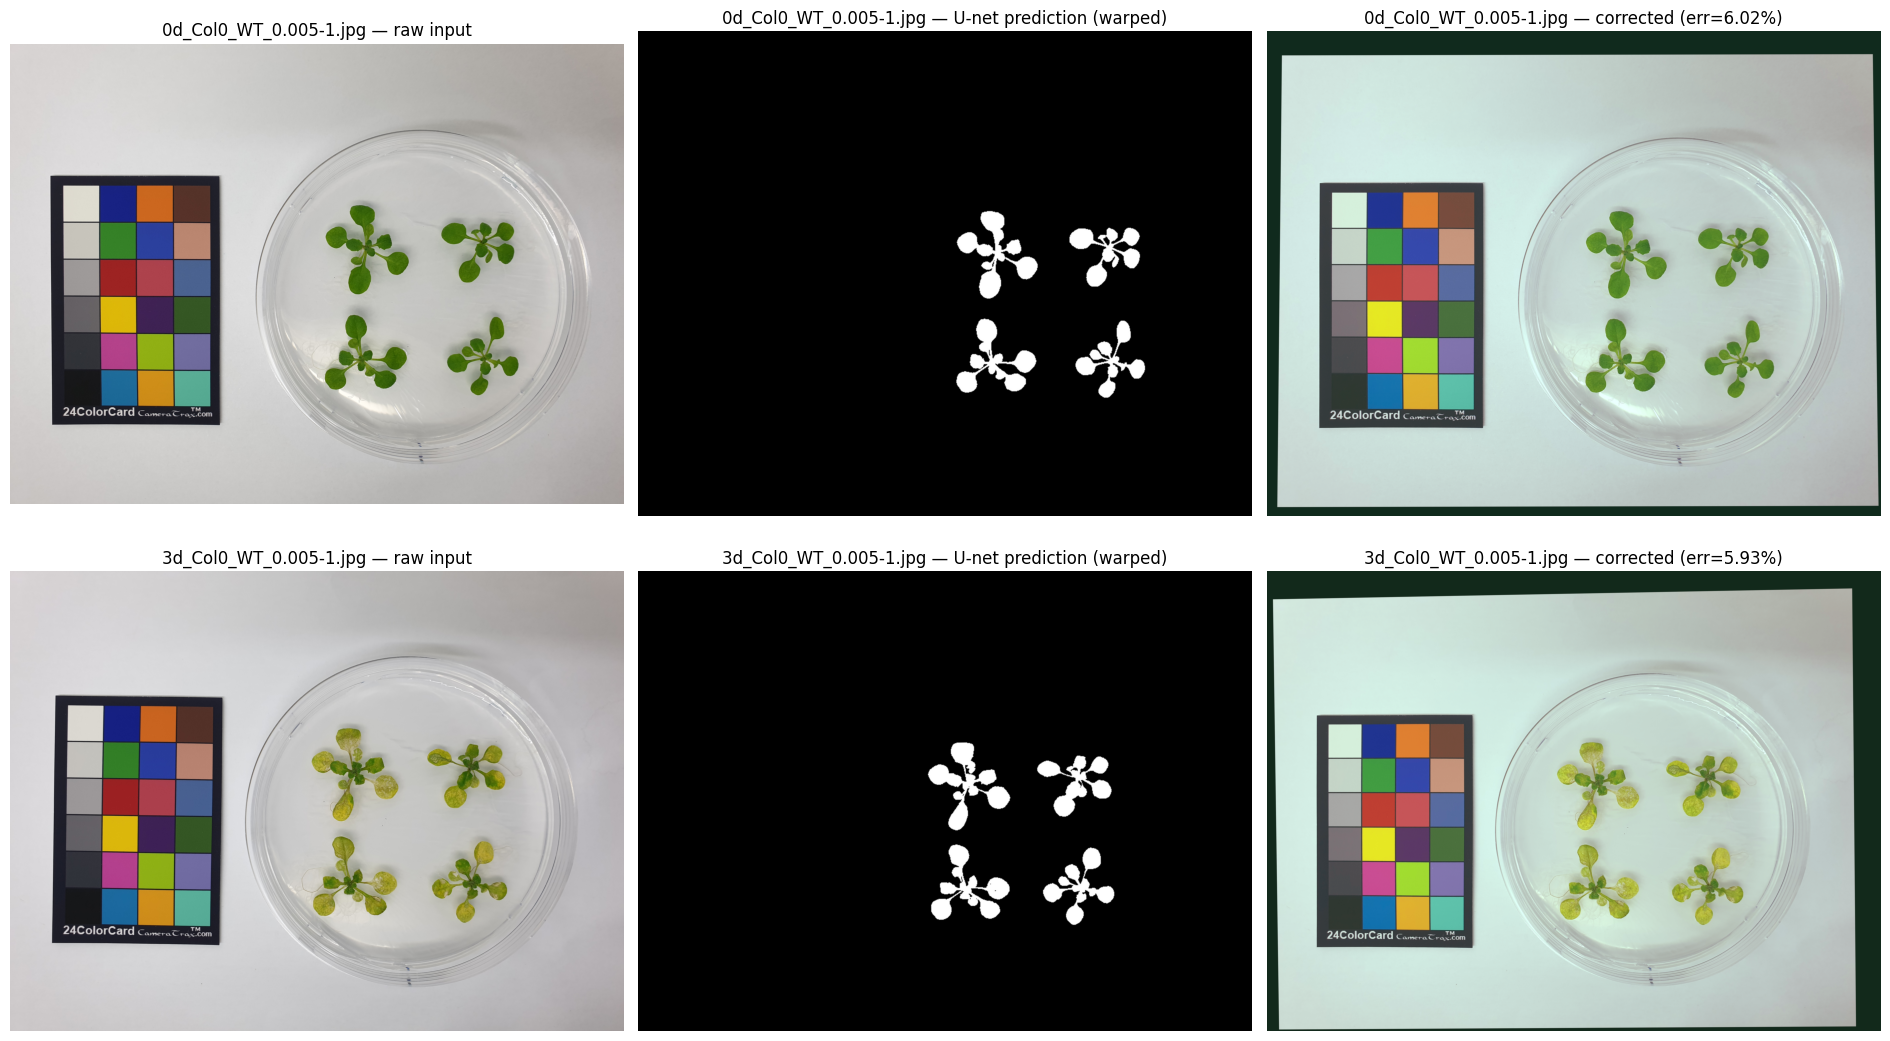

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
for row, s in enumerate(SAMPLES):
    d = diagnostics[s]
    axes[row, 0].imshow(cv2.cvtColor(d['input_rot'], cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f'{s} — raw input')
    axes[row, 1].imshow(d['warped_mask'], cmap='gray')
    axes[row, 1].set_title(f'{s} — U-net prediction (warped)')
    axes[row, 2].imshow(d['corrected_rgb'])
    axes[row, 2].set_title(f"{s} — corrected (err={d['correction_error_pct']}%)")
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout(); plt.show()

## 11. Per-seedling trait distributions (additional visualization)

A notebook-generated graph (not an author figure): projected leaf area and GCC per
seedling at 0d vs 3d, showing the within-plate spread the CSV encodes.

**日本語:** 個体ごとの面積と GCC を 0d/3d で比較した追加グラフです (論文の図ではありません)。

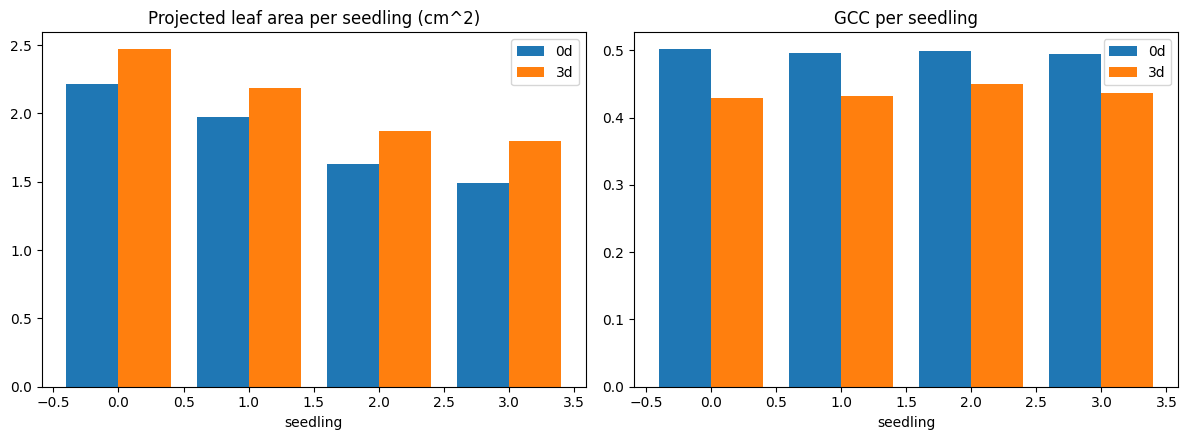

In [ ]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(d0))
axes[0].bar(x - 0.2, d0['Projected leaf area (cm^2)'], 0.4, label='0d')
axes[0].bar(x + 0.2, d3['Projected leaf area (cm^2)'], 0.4, label='3d')
axes[0].set_title('Projected leaf area per seedling (cm^2)'); axes[0].set_xlabel('seedling'); axes[0].legend()
axes[1].bar(x - 0.2, d0['GCC'], 0.4, label='0d')
axes[1].bar(x + 0.2, d3['GCC'], 0.4, label='3d')
axes[1].set_title('GCC per seedling'); axes[1].set_xlabel('seedling'); axes[1].legend()
plt.tight_layout(); plt.show()

## 12. Interpretation, limitations and validation record

**What was validated (2026-10-07, fresh Colab CPU runtime):** the authors' trained YOLOv4
detector finds the four card patches (confidences ~ 1.0), the homography maps them to the
hardcoded 6.7 x 4.4 cm card rectangle (`new_scale` ~ 200 px/cm), the modified-gamma fit
against the recovered CameraTrax reference reaches a mean patch error well below the app's
20 % acceptance threshold, the U-net yields up to four seedling instances per plate (the
system's design maximum), and the 15-column trait CSV matches the app's column schema.

**Limitations**
- One paired plate (replicate 1, OD 0.005) — the paper's Case Study I statistics average six seedlings x six replicates x six inoculum doses; nothing here validates dataset-level accuracy.
- The app's dense-CRF mask refinement is omitted; masks are the raw U-net sigmoid > 0.5. Detected masks are model predictions, not author annotations.
- The `colorcard` retinanet `.h5` could not be loaded in modern TensorFlow (legacy serialization); the authors' own alternative `colorcard2` Darknet path was used instead.
- The released package states "tested on Windows 10" and carries no license file; redistribution terms are unclear, so the notebook downloads the author archives directly instead of bundling anything.

**Sources:** Lee et al., Plant Methods 20:44 (2024) — Implementation / Trait quantification
sections; released AraDQ v0.1.3 package (models + app modules, decompiled for constants);
`kist-smartfarm/AraDQ` README (Drive links). PhenoPaper investigation
`p-c900721bb15ebda5e76a1dc19ac75f74-20260930T035955Z-3240016` was used as prior research
guidance; all parameters above were re-verified against primary sources.

**日本語:** 著者モデル推論 + アプリ内蔵定数による最小例の実行が検証済み。単反復であり
論文のデータセット統計は検証していない。CRF 省略など偏差は各セルに記載。